# Preparation for Lab 1 - Northe, Velez, Wörner


The source code and the binaries from the spectrum analyzer from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab1_Network_Analysis).

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import mu_0

## Task 1

Insert solution here

## Task 2

### a) Sketch the measurement setup of the amplifier measurement, which is described in Task 8 of the experimental tasks.

![pic](Prelim_Task3_Circuit.png)

### b) Find maximum power levels according to specifications of a network analyzer (input and output).

As there wasn't a specific model stated, we used this [Rohde & Schwarz ZNA67 datasheet](https://scdn.rohde-schwarz.com/ur/pws/dl_downloads/pdm/cl_brochures_and_datasheets/specifications/5215_4652_22/ZNA_specs_en_5215-4652-22_v2100.pdf)

**Output Test Port from page 24**

![title](ZNA67_max_power_level.png)

**Maximum Input Level from page 27**

At $+27dBm$ is the maximum power level, which can be accepted.

![title](ZNA67_max_damage_level.png)

### c) Determine the maximum allowed output power of a network analyzer for the amplifier of Task 8 without damaging the VNA.

Used [Datasheet of NLB-300](https://www.alldatasheet.com/datasheet-pdf/download/103781/RFMD/NLB-300.html)

The maximum allowed output power of the analyzer is limited to the maximum input values from the LNA. Here the datasheet states that $+20dBm$. <br>
But it has to be considered that the LNA is here way past its designed specifications. At this input level we exceed other parameters like 1dB-Compression point depending on the frequency at $\approx 13dBm$. 

## Task 3

### How do the 16-term, 12-term and 8-term error models differ? Specify the conditions that are assumed to apply to each.

## Task 4

### Why is a cable usually standardized to 50 Ohm in microwave technology? What are the advantages?

In [12]:
f = 10e9    # [Hz]
D = 10e-3   # [m]

sigma_cu = 5.8e7  # conductivity of copper (S/m)
e_r = 1.0

## Conductor Loss in Coaxial Cable Due to Skin Effect

We derive the attenuation per unit length $\alpha$ of a coaxial cable due to conductor loss, assuming high frequency (skin effect dominates) and no dielectric loss.

---

### 1. Characteristic Impedance

For a coaxial cable with:

- Inner conductor diameter: $d$
- Outer conductor inner diameter: $D$
- Relative permittivity: $\varepsilon_r$

The characteristic impedance is [1]:

$$
Z_0 = \frac{60}{\sqrt{\varepsilon_r}} \ln \left( \frac{D}{d} \right)
$$

For an **air dielectric** $\varepsilon_r = 1$:

$$
Z_0 = 60 \ln \left( \frac{D}{d} \right)
$$

---

### 2. Surface Resistance Due to Skin Effect

At high frequencies, current flows only on the surface of conductors. The **surface resistance** is:

$$
R_s = \sqrt{ \frac{ \pi f \mu }{ \sigma } }
$$

Where:

- $f$: frequency (Hz)  
- $\mu$: magnetic permeability of conductor (use $\mu_0 = 4\pi \times 10^{-7} \,\mathrm{H/m}$ for copper)  
- $\sigma$: electrical conductivity (for copper, $ \sigma = 5.8 \times 10^7 \,\mathrm{S/m} $)  

---

### 3. Conductor Attenuation (in Np/m and dB/m)

Conductor attenuation per unit length in **nepers/meter** is:

$$
\alpha_c = \frac{R_s}{Z_0} \cdot \frac{1}{\pi} \left( \frac{1}{d} + \frac{1}{D} \right)
$$

Convert to **dB/m**:

$$
\alpha_c~[\mathrm{dB/m}] = 8.686 \cdot \frac{R_s}{Z_0} \cdot \frac{1}{\pi} \left( \frac{1}{d} + \frac{1}{D} \right)
$$

[1] https://www.microwaves101.com/encyclopedias/coax-loss-calculations

## Task 3

In [13]:
# Surface resistance Rs due to skin depth
Rs = np.sqrt(np.pi * f * mu_0 / sigma_cu)

# Sweep inner conductor diameters
d_vals = np.linspace(0.1e-3, 9.9e-3, 1000)  # avoid d = D

# Calculate Z0 and alpha for each d
Z0 = (60 / np.sqrt(e_r)) * np.log(D / d_vals)
alpha_np_m = (Rs / Z0) * (1/np.pi) * (1/d_vals + 1/D)
alpha_db_m = 8.686 * alpha_np_m

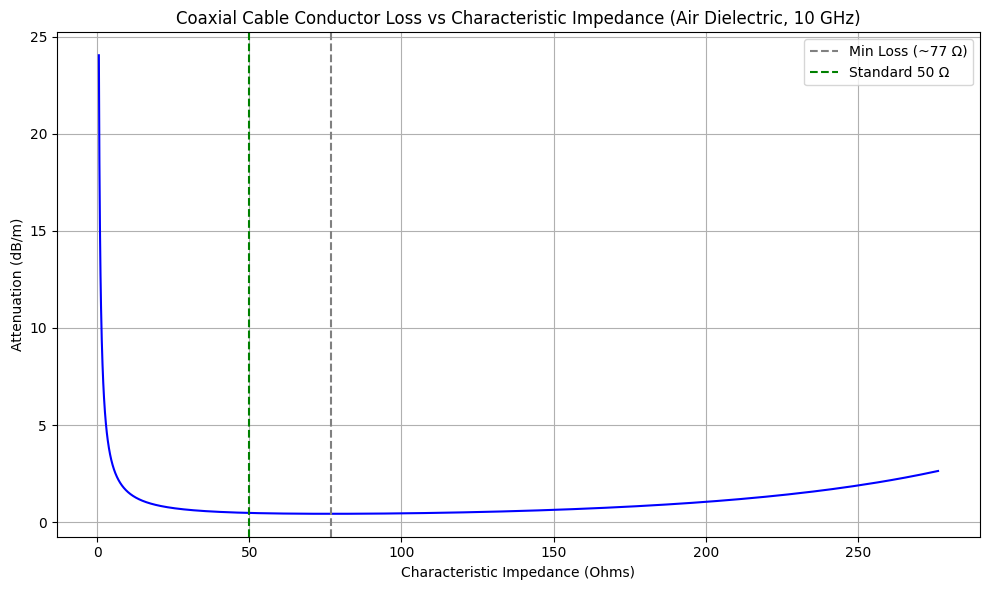

In [14]:
plt.figure(figsize=(10,6))
plt.plot(Z0, alpha_db_m, color='blue')
plt.axvline(77, color='gray', linestyle='--', label='Min Loss (~77 Ω)')
plt.axvline(50, color='green', linestyle='--', label='Standard 50 Ω')

plt.title('Coaxial Cable Conductor Loss vs Characteristic Impedance (Air Dielectric, 10 GHz)')
plt.xlabel('Characteristic Impedance (Ohms)')
plt.ylabel('Attenuation (dB/m)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Peak Power Handling of Air Dielectric Coaxial Cable

The peak power handling of an air dielectric coaxial cable is limited primarily by **voltage breakdown** rather than heating. The maximum electric field in a coaxial cable differs significantly from the simple parallel-plate model due to geometry.

---

### Field Enhancement Factor

The *field enhancement* factor \(\beta\) quantifies how much stronger the electric field is in a coax compared to a parallel-plate capacitor of the same gap:

\[
\beta = \frac{\frac{a}{r}}{\ln \left( 1 + \frac{a}{r} \right)}
\]

where:  
- \(a = \frac{D - d}{2}\) is the gap between conductors (half the difference between outer and inner diameters)  
- \(r = \frac{d}{2}\) is the radius of the inner conductor

---

### Voltage Breakdown and Maximum Power

Assuming a critical breakdown electric field \(E_\text{crit}\), the maximum voltage across the gap without breakdown is:

\[
V_\text{max} = E_\text{crit} \cdot a \cdot \beta
\]

The corresponding **peak power** handling (since power depends on \( V^2 / Z_0 \)) is:

\[
P_\text{peak} = \frac{V_\text{max}^2}{2 Z_0} = \frac{\left( E_\text{crit} \, a \, \beta \right)^2}{2 Z_0}
\]

Note: The denominator has 2 because \(V_\text{max}\) is peak voltage, and power calculations typically use RMS voltage (\(V_\text{RMS} = V_\text{peak}/\sqrt{2}\)).

---

### Summary:

\[
\boxed{
P_\text{peak} = \frac{ \left( E_\text{crit} \cdot a \cdot \frac{\frac{a}{r}}{\ln \left( 1 + \frac{a}{r} \right)} \right)^2 }{2 Z_0}
}
\]

This expression shows that peak power handling depends on the cable geometry (through \(a\) and \(r\)), the critical breakdown field \(E_\text{crit}\), and the characteristic impedance \(Z_0\).

---

### Typical Parameters:

- \(E_\text{crit} = 100\,000\, \mathrm{V/m}\) (conservative air breakdown)  
- \(d, D\) chosen such that \(Z_0\) varies  
- Note: Best peak power handling occurs near \(Z_0 \approx 30\, \Omega\)



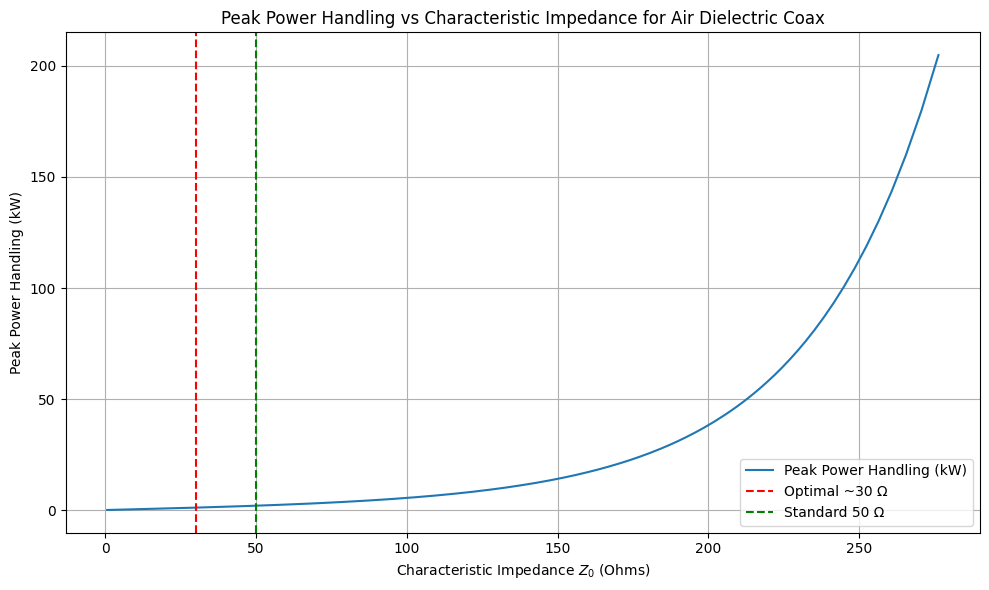

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
E_crit = 1e5  # Critical breakdown field in V/m (conservative)
mu0 = 4 * np.pi * 1e-7
sigma_cu = 5.8e7  # Copper conductivity S/m
eps_r = 1.0  # Air dielectric

# Outer conductor diameter fixed
D = 10e-3  # 10 mm outer conductor inner diameter

# Inner conductor diameters
d_vals = np.linspace(0.1e-3, 9.9e-3, 1000)  # avoid d = D

# Calculate characteristic impedance Z0
Z0 = (60 / np.sqrt(eps_r)) * np.log(D / d_vals)

# Calculate a and r
a = (D - d_vals) / 2
r = d_vals / 2

# Calculate field enhancement beta
beta = (a / r) / np.log(1 + (a / r))

# Calculate max voltage
V_max = E_crit * a * beta

# Calculate peak power handling
P_peak = V_max**2 / (2 * Z0)  # Watts

# Plot peak power vs Z0
plt.figure(figsize=(10,6))
plt.plot(Z0, P_peak / 1e3, label='Peak Power Handling (kW)')
plt.axvline(30, color='red', linestyle='--', label='Optimal ~30 Ω')
plt.axvline(50, color='green', linestyle='--', label='Standard 50 Ω')

plt.xlabel('Characteristic Impedance $Z_0$ (Ohms)')
plt.ylabel('Peak Power Handling (kW)')
plt.title('Peak Power Handling vs Characteristic Impedance for Air Dielectric Coax')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
